In [ ]:
"""
This code implements a RFM with POU for a 2D L^2 regression problem.
It uses the RMF package. 
"""
import pyrfm
import torch
import matplotlib.pyplot as plt
import numpy as np

In [2]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
def u_exact(x, k=0.5):
    '''
    x : torch.Tensor, shape (n, 2)
    z : torch.Tensor, shape (n, 1)
    ''' 
    z = torch.sin(torch.pi*k*x[:,0:1])*torch.sin(torch.pi*k*x[:,1:2] ) # * torch.sin(pi/2*x[:,2:3])  
    # z = x[:,0:1]**2 + x[:,1:2]**2
    return z 

In [11]:
neuron_num = [2**i for i in range(4,12)]
rl2_lst = []
for n in neuron_num:
    domain = pyrfm.Square2D(center=[0.5, 0.5], radius=[0.5, 0.5])

    x_train = domain.in_sample(10000)
    u_train = u_exact(x_train)

    x = torch.linspace(0,1,200)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
    u_test = u_exact(x_test)

    # for n in neuron_num:
    model = pyrfm.RFMBase(dim=2, n_hidden=n, domain=domain, n_subdomains=1, pou=pyrfm.PsiB)
    A = model.features(x_train).cat(dim=1)
    b = u_train
    model.compute(A).solve(b)
    u_pred = model(x_test)
    rl2 = ((u_test - u_pred).norm() / u_test.norm()).item()
    rl2_lst.append((n, rl2))
    print(f'# neuron {A.shape[1]} RL2 error: {rl2:.3e}')

Decomposing the problem size of A:  torch.Size([10000, 16]) with solver QR
Least Square Relative residual: 4.2895e-03
# neuron 16 RL2 error: 5.027e-03
Decomposing the problem size of A:  torch.Size([10000, 32]) with solver QR
Least Square Relative residual: 6.9426e-05
# neuron 32 RL2 error: 7.901e-05
Decomposing the problem size of A:  torch.Size([10000, 64]) with solver QR
Least Square Relative residual: 7.1180e-07
# neuron 64 RL2 error: 9.306e-07
Decomposing the problem size of A:  torch.Size([10000, 128]) with solver QR
Least Square Relative residual: 5.9008e-10
# neuron 128 RL2 error: 9.988e-10
Decomposing the problem size of A:  torch.Size([10000, 256]) with solver QR
Least Square Relative residual: 6.1077e-14
# neuron 256 RL2 error: 1.335e-13
Decomposing the problem size of A:  torch.Size([10000, 512]) with solver QR
Least Square Relative residual: 8.9956e-15
# neuron 512 RL2 error: 1.242e-14
Decomposing the problem size of A:  torch.Size([10000, 1024]) with solver QR
Least Squar

In [8]:
neuron_num = [2**i for i in range(2,10)]
rl2_list_2x2 = []
for n in neuron_num:
    domain = pyrfm.Square2D(center=[0.5, 0.5], radius=[0.5, 0.5])

    x_train = domain.in_sample(20000)
    u_train = u_exact(x_train)

    x = torch.linspace(0,1,200)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
    u_test = u_exact(x_test)

    # for n in neuron_num:
    model = pyrfm.RFMBase(dim=2, n_hidden=n, domain=domain, n_subdomains=2, pou=pyrfm.PsiB)
    A = model.features(x_train).cat(dim=1)
    b = u_train
    model.compute(A).solve(b)
    u_pred = model(x_test)
    rl2 = ((u_test - u_pred).norm() / u_test.norm()).item()
    rl2_list_2x2.append((n*4, rl2))
    print(f'# neuron {A.shape[1]} RL2 error: {rl2:.3e}')

Decomposing the problem size of A:  torch.Size([19881, 16]) with solver QR
Least Square Relative residual: 5.4725e-02
# neuron 16 RL2 error: 6.736e-02
Decomposing the problem size of A:  torch.Size([19881, 32]) with solver QR
Least Square Relative residual: 9.5602e-03
# neuron 32 RL2 error: 1.057e-02
Decomposing the problem size of A:  torch.Size([19881, 64]) with solver QR
Least Square Relative residual: 1.5005e-03
# neuron 64 RL2 error: 1.549e-03
Decomposing the problem size of A:  torch.Size([19881, 128]) with solver QR
Least Square Relative residual: 4.3576e-05
# neuron 128 RL2 error: 4.952e-05
Decomposing the problem size of A:  torch.Size([19881, 256]) with solver QR
Least Square Relative residual: 2.1799e-07
# neuron 256 RL2 error: 2.706e-07
Decomposing the problem size of A:  torch.Size([19881, 512]) with solver QR
Least Square Relative residual: 1.5877e-10
# neuron 512 RL2 error: 3.065e-10
Decomposing the problem size of A:  torch.Size([19881, 1024]) with solver QR
Least Squar

In [9]:
neuron_num = [2**i for i in range(0,8)]
rl2_list_4x4 = []
for n in neuron_num:
    domain = pyrfm.Square2D(center=[0.5, 0.5], radius=[0.5, 0.5])

    x_train = domain.in_sample(20000)
    u_train = u_exact(x_train)

    x = torch.linspace(0,1,200)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
    u_test = u_exact(x_test)

    # for n in neuron_num:
    model = pyrfm.RFMBase(dim=2, n_hidden=n, domain=domain, n_subdomains=4, pou=pyrfm.PsiB)
    A = model.features(x_train).cat(dim=1)
    b = u_train
    model.compute(A).solve(b)
    u_pred = model(x_test)
    rl2 = ((u_test - u_pred).norm() / u_test.norm()).item()
    rl2_list_4x4.append((n*16, rl2))
    print(f'# neuron {A.shape[1]} RL2 error: {rl2:.3e}')

Decomposing the problem size of A:  torch.Size([19881, 16]) with solver QR
Least Square Relative residual: 9.9922e-01
# neuron 16 RL2 error: 1.998e+00
Decomposing the problem size of A:  torch.Size([19881, 32]) with solver QR
Least Square Relative residual: 8.2649e-01
# neuron 32 RL2 error: 4.822e-01
Decomposing the problem size of A:  torch.Size([19881, 64]) with solver QR
Least Square Relative residual: 6.4464e-02
# neuron 64 RL2 error: 6.827e-02
Decomposing the problem size of A:  torch.Size([19881, 128]) with solver QR
Least Square Relative residual: 1.0398e-02
# neuron 128 RL2 error: 1.077e-02
Decomposing the problem size of A:  torch.Size([19881, 256]) with solver QR
Least Square Relative residual: 2.1137e-03
# neuron 256 RL2 error: 2.819e-03
Decomposing the problem size of A:  torch.Size([19881, 512]) with solver QR
Least Square Relative residual: 2.5439e-05
# neuron 512 RL2 error: 3.084e-05
Decomposing the problem size of A:  torch.Size([19881, 1024]) with solver QR
Least Squar

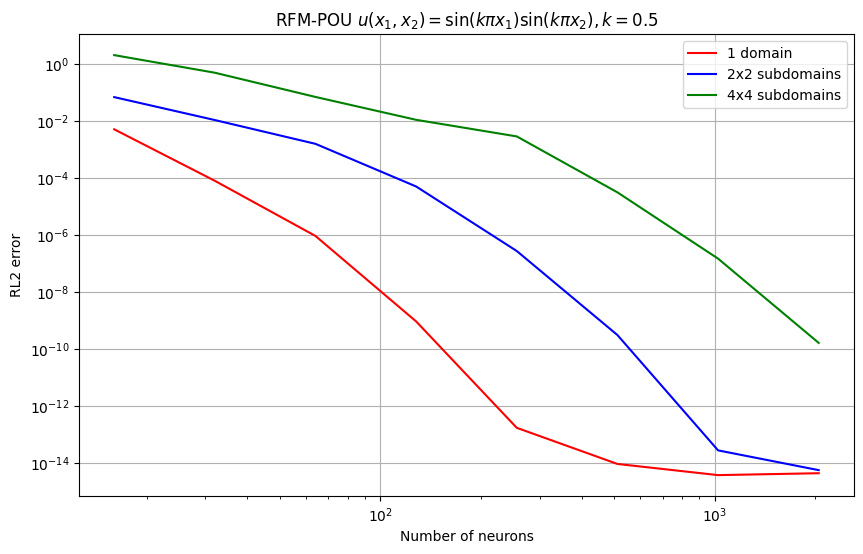

In [10]:
rl2_np = np.array(rl2_lst)
rl2_np_2x2 = np.array(rl2_list_2x2)
rl2_np_4x4 = np.array(rl2_list_4x4)

plt.figure(figsize=(10, 6))
plt.plot(rl2_np[:,0], rl2_np[:,1], '-r', label='1 domain')
plt.plot(rl2_np_2x2[:,0], rl2_np_2x2[:,1], '-b', label='2x2 subdomains')
plt.plot(rl2_np_4x4[:,0], rl2_np_4x4[:,1], '-g', label='4x4 subdomains')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of neurons')
plt.ylabel('RL2 error')
plt.legend()
plt.title('RFM-POU $u(x_1, x_2) = \sin(k\pi x_1) \sin(k\pi x_2), k=0.5$')
plt.grid()
plt.show()